In [127]:
# !pip install webdriver-manager
# !pip install scrapy_splash
# !pip install cloudscraper
#!pip install openpyxl
#!pip install selenium
#!pip install random


[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: C:\Users\diogo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement random (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.0
[notice] To update, run: C:\Users\diogo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for random


In [1]:
import requests
import scrapy
import json
from parsel import Selector
import cloudscraper
from parsel import Selector
import pandas as pd

In [129]:
import cloudscraper
from parsel import Selector
import pandas as pd
import json
from time import datetime

# Função para extrair dados de todas as páginas
def scrape_olx(headers, start_page=1, end_page=100):
    scraper = cloudscraper.create_scraper()
    all_casas = []

    for page in range(start_page, end_page + 1):
        url = f'https://www.olx.com.br/estado-mg?q=apartamento+bairro+lourdes%2C+em+belo+horizonte-mg&o={page}'
        r = scraper.get(url, headers=headers)

        if r.status_code == 200:  # Verifica se a requisição foi bem-sucedida
            s = Selector(text=r.text)
            script_data = s.xpath('//script[@id="__NEXT_DATA__"]/text()').get()

            if script_data:
                html = json.loads(script_data)
                casas = html.get('props', {}).get('pageProps', {}).get('ads', [])
                all_casas.extend(casas)
            else:
                print(f"Script data not found on page {page}")
        else:
            print(f"Failed to fetch page {page}: {r.status_code}")

    return all_casas

# Função para converter os dados em um DataFrame
def casas_to_dataframe(casas):
    rows = []
    for casa in casas:
        row = {
            'Título': casa.get('title'),
            'Preço': casa.get('price'),
            'ID do Anúncio': casa.get('listId'),
            'Localização': casa.get('location'),
            'Município': casa.get('locationDetails', {}).get('municipality'),
            'DDD': casa.get('locationDetails', {}).get('ddd'),
            'Bairro': casa.get('locationDetails', {}).get('neighbourhood'),
            'Estado': casa.get('locationDetails', {}).get('uf'),
            'Categoria': casa.get('category'),
            'Tipo': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'real_estate_type'), None),
            'Condomínio': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'condominio'), None),
            'IPTU': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'iptu'), None),
            'Área Útil': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'size'), None),
            'Quartos': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'rooms'), None),
            'Banheiros': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'bathrooms'), None),
            'Vagas na Garagem': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'garage_spaces'), None)
        }
        rows.append(row)
        print(row)
    return pd.DataFrame(rows)

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36'
}

casas = scrape_olx(headers, start_page=1, end_page=100)
df_casas = casas_to_dataframe(casas)




Failed to fetch page 97: 502
{'Título': 'Venda de Apartamento em Belo Horizonte-MG, bairro Lourdes', 'Preço': 'R$ 650.000', 'ID do Anúncio': 1374136499, 'Localização': 'Belo Horizonte, Centro - DDD 31', 'Município': 'Belo Horizonte', 'DDD': '31', 'Bairro': 'Centro', 'Estado': 'MG', 'Categoria': 'Apartamentos', 'Tipo': 'Venda - apartamento padrão', 'Condomínio': 'R$ 597', 'IPTU': 'R$ 177', 'Área Útil': '115m²', 'Quartos': '3', 'Banheiros': '2', 'Vagas na Garagem': '1'}
{'Título': 'Apartamento 02 quartos à venda no bairro de Lourdes próximo a Praça Marília de Dirceu', 'Preço': 'R$ 1.480.000', 'ID do Anúncio': 1374007700, 'Localização': 'Belo Horizonte, Lourdes - DDD 31', 'Município': 'Belo Horizonte', 'DDD': '31', 'Bairro': 'Lourdes', 'Estado': 'MG', 'Categoria': 'Apartamentos', 'Tipo': 'Venda - apartamento padrão', 'Condomínio': 'R$ 1.641', 'IPTU': 'R$ 6.607', 'Área Útil': '73m²', 'Quartos': '2', 'Banheiros': '3', 'Vagas na Garagem': '2'}
{'Título': 'Apartamento à venda no bairro Lourde

# WEBSCRAPING

In [ ]:
import cloudscraper
from parsel import Selector
import pandas as pd
import json
import time
from datetime import datetime

CONFIG = {
    'AUTOTHROTTLE_ENABLED': True, 
    'MAX_RETRIES': 3,  
    'THROTTLE_DELAY': 3,  
}

def scrape_olx(headers, start_page=1, end_page=101):
    scraper = cloudscraper.create_scraper()
    all_casas = []

    for page in range(start_page, end_page + 1):
        retries = 0
        while retries < CONFIG['MAX_RETRIES']:
            url = f'https://www.olx.com.br/imoveis/estado-mg/belo-horizonte-e-regiao/zona-centro-sul/lourdes?o={page}'
            try:
                r = scraper.get(url, headers=headers)

                if r.status_code == 200:  # Verifica se a requisição foi bem-sucedida
                    s = Selector(text=r.text)
                    script_data = s.xpath('//script[@id="__NEXT_DATA__"]/text()').get()

                    if script_data:
                        html = json.loads(script_data)
                        casas = html.get('props', {}).get('pageProps', {}).get('ads', [])
                        all_casas.extend(casas)
                        print(f"✅ Página {page} coletada com sucesso.")
                        break
                    else:
                        print(f"⚠️ Dados não encontrados na página {page}. Tentando novamente...")

                else:
                    print(f"❌ Erro {r.status_code} na página {page}. Tentando novamente...")

            except Exception as e:
                print(f"⚠️ Erro ao coletar a página {page}: {e}. Tentando novamente...")

            retries += 1
            time.sleep(CONFIG['THROTTLE_DELAY'])  # Aguarda antes de tentar novamente

        if retries == CONFIG['MAX_RETRIES']:
            print(f"❌ Falha ao coletar a página {page} após {CONFIG['MAX_RETRIES']} tentativas.")

    return all_casas

def casas_to_dataframe(casas):
    rows = []
    for casa in casas:
        timestamp = casa.get('date')
        formatted_date = datetime.fromtimestamp(timestamp).strftime('%d/%m às %H:%M') if timestamp else None
        row = {
            'Título': casa.get('title'),
            'Preço': casa.get('price'),
            'ID do Anúncio': casa.get('listId'),
            'Localização': casa.get('location'),
            'Município': casa.get('locationDetails', {}).get('municipality'),
            'DDD': casa.get('locationDetails', {}).get('ddd'),
            'Bairro': casa.get('locationDetails', {}).get('neighbourhood'),
            'Estado': casa.get('locationDetails', {}).get('uf'),
            'Categoria': casa.get('category'),
            'Tipo': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'real_estate_type'), None),
            'Condomínio': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'condominio'), None),
            'IPTU': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'iptu'), None),
            'Área Útil': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'size'), None),
            'Quartos': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'rooms'), None),
            'Banheiros': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'bathrooms'), None),
            'Vagas na Garagem': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'garage_spaces'), None),
            'Data Anúncio': formatted_date  
        }
        rows.append(row)
        print(f"✅ Anúncio coletado: {row['Título']} | Preço: {row['Preço']}")
    return pd.DataFrame(rows)

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36'
}

casas = scrape_olx(headers, start_page=1, end_page=100)
df_casas = casas_to_dataframe(casas)
#df_casas.to_('casas_olx.xlsx')


✅ Página 1 coletada com sucesso.
✅ Página 2 coletada com sucesso.
✅ Página 3 coletada com sucesso.
✅ Página 4 coletada com sucesso.
✅ Página 5 coletada com sucesso.
✅ Página 6 coletada com sucesso.
✅ Página 7 coletada com sucesso.
✅ Página 8 coletada com sucesso.
✅ Página 9 coletada com sucesso.
✅ Página 10 coletada com sucesso.
✅ Página 11 coletada com sucesso.
✅ Página 12 coletada com sucesso.
✅ Página 13 coletada com sucesso.
✅ Página 14 coletada com sucesso.
✅ Página 15 coletada com sucesso.
✅ Página 16 coletada com sucesso.
✅ Página 17 coletada com sucesso.
✅ Página 18 coletada com sucesso.
✅ Página 19 coletada com sucesso.
✅ Página 20 coletada com sucesso.
✅ Página 21 coletada com sucesso.
✅ Página 22 coletada com sucesso.
✅ Página 23 coletada com sucesso.
✅ Página 24 coletada com sucesso.
✅ Página 25 coletada com sucesso.
✅ Página 26 coletada com sucesso.
✅ Página 27 coletada com sucesso.
✅ Página 28 coletada com sucesso.
✅ Página 29 coletada com sucesso.
✅ Página 30 coletada co

In [ ]:
df_casas

In [41]:
def casas_to_dataframe(casas):
    empreendimentos = []
    tipologias = []
    unidades = []

    for casa in casas:
        timestamp = casa.get('date')
        formatted_date = datetime.fromtimestamp(timestamp).strftime('%d/%m às %H:%M') if timestamp else None

        empreendimento_nome = casa.get('locationDetails', {}).get('neighbourhood', 'Desconhecido')
        empreendimento_endereco = casa.get('location')
        
        empreendimento_id = f"{empreendimento_nome}_{empreendimento_endereco}"

        quartos = next((p['value'] for p in casa.get('properties', []) if p['name'] == 'rooms'), None)
        banheiros = next((p['value'] for p in casa.get('properties', []) if p['name'] == 'bathrooms'), None)
        tipologia_id = f"{empreendimento_id}_Q{quartos}_B{banheiros}"

        # Empreendimentos
        empreendimentos.append({
            'Empreendimento': empreendimento_id,
            'ID do Anúncio': casa.get('listId'),
            'Nome': empreendimento_nome,
            'Endereço': empreendimento_endereco,
            'Bairro': casa.get('locationDetails', {}).get('neighbourhood'),
            'Município': casa.get('locationDetails', {}).get('municipality'),
            'Estado': casa.get('locationDetails', {}).get('uf'),
        })

        # Tipologias
        tipologias.append({
            'Tipologia': tipologia_id,
            'ID do Anúncio': casa.get('listId'),
            'Empreendimento': empreendimento_id,
            'Número de Quartos': quartos,
            'Número de Banheiros': banheiros,
            'Área Útil': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'size'), None),
            'Vagas na Garagem': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'garage_spaces'), None),
            'Preço Médio': casa.get('price'),
        })

        # Unidades
        unidades.append({
            'Tipologia': tipologia_id,
            'ID do Anúncio': casa.get('listId'),
            'Título': casa.get('title'),
            'Preço': casa.get('price'),
            'Condomínio': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'condominio'), None),
            'IPTU': next((p['value'] for p in casa.get('properties', []) if p['name'] == 'iptu'), None),
            'Data do Anúncio': formatted_date,
        })

    return pd.DataFrame(empreendimentos).drop_duplicates(), pd.DataFrame(tipologias).drop_duplicates(), pd.DataFrame(unidades).drop_duplicates()

def salvar_dados(empreendimentos, tipologias, unidades):
    data_atual = datetime.now().strftime("%Y-%m")
    
    empreendimentos.to_csv(f"empreendimentos_{data_atual}.csv", index=False)
    tipologias.to_csv(f"tipologias_{data_atual}.csv", index=False)
    unidades.to_csv(f"unidades_{data_atual}.csv", index=False)
    
    print(f"📁 Dados salvos com sucesso para {data_atual}!")

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/131.0.0.0 Safari/537.36'
}

casas = scrape_olx(headers, start_page=1, end_page=101)

df_empreendimentos, df_tipologias, df_unidades = casas_to_dataframe(casas)

salvar_dados(df_empreendimentos, df_tipologias, df_unidades)


✅ Página 1 coletada com sucesso.
✅ Página 2 coletada com sucesso.
✅ Página 3 coletada com sucesso.
✅ Página 4 coletada com sucesso.
✅ Página 5 coletada com sucesso.
✅ Página 6 coletada com sucesso.
✅ Página 7 coletada com sucesso.
✅ Página 8 coletada com sucesso.
✅ Página 9 coletada com sucesso.
✅ Página 10 coletada com sucesso.
✅ Página 11 coletada com sucesso.
✅ Página 12 coletada com sucesso.
✅ Página 13 coletada com sucesso.
✅ Página 14 coletada com sucesso.
✅ Página 15 coletada com sucesso.
✅ Página 16 coletada com sucesso.
✅ Página 17 coletada com sucesso.
✅ Página 18 coletada com sucesso.
✅ Página 19 coletada com sucesso.
✅ Página 20 coletada com sucesso.
✅ Página 21 coletada com sucesso.
✅ Página 22 coletada com sucesso.
✅ Página 23 coletada com sucesso.
✅ Página 24 coletada com sucesso.
✅ Página 25 coletada com sucesso.
✅ Página 26 coletada com sucesso.
✅ Página 27 coletada com sucesso.
✅ Página 28 coletada com sucesso.
✅ Página 29 coletada com sucesso.
✅ Página 30 coletada co

In [42]:
df_empreendimentos
#df_casas[0]

,Empreendimento,ID do Anúncio,Nome,Endereço,Bairro,Município,Estado
0,"Lourdes_Belo Horizonte, Lourdes",1.372309e+09,Lourdes,"Belo Horizonte, Lourdes",Lourdes,Belo Horizonte,MG
1,"Lourdes_Belo Horizonte, Lourdes",1.365816e+09,Lourdes,"Belo Horizonte, Lourdes",Lourdes,Belo Horizonte,MG
2,"Lourdes_Belo Horizonte, Lourdes",1.371951e+09,Lourdes,"Belo Horizonte, Lourdes",Lourdes,Belo Horizonte,MG
3,"Lourdes_Belo Horizonte, Lourdes",1.296147e+09,Lourdes,"Belo Horizonte, Lourdes",Lourdes,Belo Horizonte,MG
4,"Lourdes_Belo Horizonte, Lourdes",1.374410e+09,Lourdes,"Belo Horizonte, Lourdes",Lourdes,Belo Horizonte,MG
...,...,...,...,...,...,...,...
5497,"Lourdes_Belo Horizonte, Lourdes",1.047862e+09,Lourdes,"Belo Horizonte, Lourdes",Lourdes,Belo Horizonte,MG
5498,"Lourdes_Belo Horizonte, Lourdes",9.487166e+08,Lourdes,"Belo Horizonte, Lourdes",Lourdes,Belo Horizonte,MG
5499,"Lourdes_Belo Horizonte, Lourdes",1.130334e+09,Lourdes,"Belo Horizonte, Lourdes",Lourdes,Belo Horizonte,MG
5500,"Lourdes_Belo Horizonte, Lourdes",9.931136e+08,Lourdes,"Belo Horizonte, Lourdes",Lourdes,Belo Horizonte,MG


# OLX DUPLICADOS

In [43]:

if isinstance(df_casas, list):
    df_casas = pd.DataFrame(df_casas)

print("Colunas disponíveis no DataFrame:")


duplicated = df_casas.duplicated(subset=['Categoria', 'IPTU', 'Área Útil', 'Quartos', 'Banheiros', 'Vagas na Garagem'], keep=False)
duplicated
duplicated_rows = df_casas[duplicated]
duplicated_rows[duplicated_rows['Título']=='CARNAVAL - BH - 2025 - 30 HÓSPEDES']

duplicated_rows_sorted = duplicated_rows.sort_values(by='Título', ascending=True)
duplicated_rows_sorted




Colunas disponíveis no DataFrame:


,Título,Preço,ID do Anúncio,Localização,Município,DDD,Bairro,Estado,Categoria,Tipo,Condomínio,IPTU,Área Útil,Quartos,Banheiros,Vagas na Garagem,Data Anúncio
1705,"02 Quartos, suíte e 02 vagas no Lourdes",R$ 5.400,1.354808e+09,"Belo Horizonte, Lourdes",Belo Horizonte,31,Lourdes,MG,Apartamentos,Aluguel - apartamento padrão,R$ 895,R$ 0,63m²,2,2,2,15/11 às 04:37
1706,"02 Quartos, suíte, academia e 02 vagas próximo...",R$ 5.400,1.354808e+09,"Belo Horizonte, Lourdes",Belo Horizonte,31,Lourdes,MG,Apartamentos,Aluguel - apartamento padrão,R$ 895,R$ 0,63m²,2,2,2,15/11 às 04:37
224,02 quartos a venda no Lourdes,R$ 1.128.997,1.372621e+09,"Belo Horizonte, Lourdes",Belo Horizonte,31,Lourdes,MG,Apartamentos,Venda - apartamento padrão,R$ 0,R$ 0,67m²,2,3,2,23/01 às 11:16
191,02 quartos a venda no Lourdes,R$ 1.128.997,1.372621e+09,"Belo Horizonte, Lourdes",Belo Horizonte,31,Lourdes,MG,Apartamentos,Venda - apartamento padrão,R$ 0,R$ 0,69m²,2,3,2,23/01 às 11:17
193,02 quartos a venda no Lourdes,R$ 1.235.649,1.372621e+09,"Belo Horizonte, Lourdes",Belo Horizonte,31,Lourdes,MG,Apartamentos,Venda - apartamento padrão,R$ 0,R$ 0,71m²,2,3,2,23/01 às 11:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5452,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None
5458,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None
5469,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None
5480,None,None,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [44]:
total_empreendimentos = df_empreendimentos.shape[0]
print(f"Quantidade total de empreendimentos identificados: {total_empreendimentos}")


Quantidade total de empreendimentos identificados: 5001


In [45]:
tipologias_frequentes = df_tipologias['Número de Quartos'].value_counts()
print("Tipologias mais frequentes:")
tipologias_frequentes

tipologias_frequentes = tipologias_frequentes.reset_index()
tipologias_frequentes.columns = ['Quantidade quartos', 'Quantidade Imoveis']
#tipologias_frequentes = pd.DataFrame(tipologias_frequentes).reset_index()
tipologias_frequentes

Tipologias mais frequentes:


,Quantidade quartos,Quantidade Imoveis
0,2,1220
1,4,1086
2,3,991
3,1,438
4,5 ou mais,75
5,0,35


In [59]:
df_unidades['Preço'] = df_unidades['Preço'].replace('[^0-9]', '', regex=True).astype(float)

df_tipologias['Área Útil'] = df_tipologias['Área Útil'].replace('[^0-9]', '', regex=True).astype(float)
df_unidades['Preço por m²'] = df_unidades['Preço'] / df_tipologias['Área Útil']
df_unidades
faixa_preco = df_unidades.groupby(pd.cut(df_unidades['Preço por m²'], bins=[0, 5000, 10000, 15000, 20000, 25000])).size()
faixa_preco_df = faixa_preco.reset_index()
faixa_preco_df.columns = ['Faixa de Preço (R$) por m²', 'Quantidade Imoveis']

faixa_preco = pd.DataFrame(faixa_preco_df)
faixa_preco

C:\Users\diogo\AppData\Local\Temp\ipykernel_121032\2352673038.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  faixa_preco = df_unidades.groupby(pd.cut(df_unidades['Preço por m²'], bins=[0, 5000, 10000, 15000, 20000, 25000])).size()


,Faixa de Preço (R$) por m²,Quantidade Imoveis
0,"(0, 5000]",1380
1,"(5000, 10000]",855
2,"(10000, 15000]",1285
3,"(15000, 20000]",1019
4,"(20000, 25000]",354


# VIVALREAL

In [133]:
import cloudscraper
from bs4 import BeautifulSoup
import pandas as pd

"https://www.vivareal.com.br/venda/minas-gerais/belo-horizonte/bairros/lourdes/"


# URL do site
url = f"https://www.vivareal.com.br/venda/minas-gerais/belo-horizonte/bairros/lourdes/?pagina={page}#onde=Brasil,Minas%20Gerais,Belo%20Horizonte,Bairros,Lourdes,,,,BR%3EMinas%20Gerais%3ENULL%3EBelo%20Horizonte%3EBarrios%3ELourdes,,,"
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36'
}

scraper = cloudscraper.create_scraper()

response = scraper.get(url, headers=headers)

if response.status_code == 200:
    soup = BeautifulSoup(response.text, 'html.parser')
    
    results_list = soup.find('div', class_='results-list js-results-list')
    
    if results_list:
        ids = [div.get('id') for div in results_list.find_all('div', attrs={'id': True})]
        
        print("IDs coletados:")
        for item_id in ids:
            print(item_id)
    else:
        print("A área dos resultados não foi encontrada no HTML.")
else:
    print(f"Erro: {response.status_code}")






IDs coletados:
2773572370
2717005821
2773870114
2773569946
2599273354
2773575216
2732207714
2773573928
2621426526
2621695075
2621695776
2765438240
2774247519
2688582831
2773533124
2702351341
2676068626
2672655987
2773572360
2565050362
2626238493
2655463166
2642009438
2771789721
2553481518
2697752681
2765165121
2654717072
2625829884
2774295448
2765614444
2730761735
2732189534
2621697680
2742961354
2723062158


In [111]:
# import cloudscraper
# from bs4 import BeautifulSoup
# import pandas as pd
# import re

# def scrape_vivareal(headers, start_page=1, end_page=5):
#     scraper = cloudscraper.create_scraper()
#     all_imoveis = []

#     for page in range(start_page, end_page + 1):
#         print(f"Coletando dados da página {page}...")
#         time.sleep(20)
#         url = f"https://www.vivareal.com.br/venda/minas-gerais/belo-horizonte/bairros/lourdes/?pagina={page}#onde=Brasil,Minas%20Gerais,Belo%20Horizonte,Bairros,Lourdes,,,,BR%3EMinas%20Gerais%3ENULL%3EBelo%20Horizonte%3EBarrios%3ELourdes,,,"

#         response = scraper.get(url, headers=headers)
        
#         if response.status_code == 200:
#             soup = BeautifulSoup(response.text, 'html.parser')

#             property_cards = soup.find_all('article', class_='property-card__container')

#             for card in property_cards:
#                 titulo = card.find('span', class_='property-card__title').get_text(strip=True) if card.find('span', class_='property-card__title') else None
#                 endereco = card.find('span', class_='property-card__address').get_text(strip=True) if card.find('span', class_='property-card__address') else None
                
#                 preco_div = card.find('div', class_='property-card__price js-property-card-prices js-property-card__price-small')
#                 preco = preco_div.find('p').get_text(strip=True) if preco_div and preco_div.find('p') else None

#                 area = card.find('span', class_='property-card__detail-value js-property-card-detail-area').get_text(strip=True) if card.find('span', class_='property-card__detail-value js-property-card-detail-area') else None
#                 quartos = card.find('li', class_='property-card__detail-room')
#                 quartos = quartos.find('span', class_='property-card__detail-value').get_text(strip=True) if quartos else None
#                 banheiros = card.find('li', class_='property-card__detail-bathroom')
#                 banheiros = banheiros.find('span', class_='property-card__detail-value').get_text(strip=True) if banheiros else None
#                 vagas = card.find('li', class_='property-card__detail-garage')
#                 vagas = vagas.find('span', class_='property-card__detail-value').get_text(strip=True) if vagas else None

#                 all_imoveis.append({
#                     'Título': titulo,
#                     'Endereço': endereco,
#                     'Preço': preco,
#                     'Área': area,
#                     'Quartos': quartos,
#                     'Banheiros': banheiros,
#                     'Vagas': vagas,
#                     'Página': page  
#                 })

#         else:
#             print(f" Erro ao acessar a página {page}. Código HTTP: {response.status_code}")

#     df_imoveis = pd.DataFrame(all_imoveis)
#     print("Coleta finalizada. Total de imóveis coletados:", len(df_imoveis))

#     df_imoveis.to_csv('imoveis_vivareal.csv', index=False, encoding='utf-8')
#     return df_imoveis

# headers = {
#     'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36',
#     'Cache-Control': 'no-cache'
# }


# df_imoveis = scrape_vivareal(headers, start_page=1, end_page=5)
# residencial = [
#     "Apartamento", "Casa", "Casa de Condomínio", "Cobertura", "Flat",
#     "Kitnet/Conjugado", "Lote/Terreno", "Sobrado", "Edifício Residencial",
#     "Fazenda/Sítios/Chácaras"
# ]

# comercial = [
#     "Consultório", "Galpão/Depósito/Armazém", "Imóvel Comercial",
#     "Lote/Terreno", "Ponto Comercial/Loja/Box", "Sala/Conjunto",
#     "Prédio/Edifício Inteiro"
# ]

# def categorizar_titulo(titulo, categorias):
#     for categoria in categorias:
#         if categoria in titulo:
#             return categoria
#     return None

# df_imoveis['Residencial'] = df_imoveis['Título'].apply(lambda x: categorizar_titulo(x, residencial))
# df_imoveis['Comercial'] = df_imoveis['Título'].apply(lambda x: categorizar_titulo(x, comercial))


# def extrair_metros(titulo):
#     match = re.search(r'\d+\s*m²', titulo)
#     if match:
#         return match.group().strip()
#     return None

# # Aplicar a função ao DataFrame e criar a nova coluna 'Metros'
# df_imoveis['Metros'] = df_imoveis['Título'].apply(extrair_metros)
import cloudscraper
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

def scrape_vivareal(headers, start_page=1, end_page=5):
    scraper = cloudscraper.create_scraper()
    all_imoveis = []

    for page in range(start_page, end_page + 1):
        print(f"Coletando dados da página {page}...")
        time.sleep(5)  # Atraso para evitar bloqueios

        # Construindo o URL
        url = f"https://www.vivareal.com.br/venda/minas-gerais/belo-horizonte/bairros/lourdes/?pagina={page}"
        print(f"URL acessado: {url}")

        # Fazendo a requisição
        response = scraper.get(url, headers=headers)

        # Salvar HTML para debug
        with open(f'pagina_{page}.html', 'w', encoding='utf-8') as file:
            file.write(response.text)

        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            property_cards = soup.find_all('article', class_='property-card__container')

            # Validar se há cards na página
            if not property_cards:
                print(f"⚠️ Nenhum imóvel encontrado na página {page}. Encerrando coleta.")
                break

            # Processar cada card
            for card in property_cards:
                titulo = card.find('span', class_='property-card__title').get_text(strip=True) if card.find('span', class_='property-card__title') else None
                endereco = card.find('span', class_='property-card__address').get_text(strip=True) if card.find('span', class_='property-card__address') else None

                preco_div = card.find('div', class_='property-card__price js-property-card-prices js-property-card__price-small')
                preco = preco_div.find('p').get_text(strip=True) if preco_div and preco_div.find('p') else None

                area = card.find('span', class_='property-card__detail-value js-property-card-detail-area').get_text(strip=True) if card.find('span', class_='property-card__detail-value js-property-card-detail-area') else None
                quartos = card.find('li', class_='property-card__detail-room')
                quartos = quartos.find('span', class_='property-card__detail-value').get_text(strip=True) if quartos else None
                banheiros = card.find('li', class_='property-card__detail-bathroom')
                banheiros = banheiros.find('span', class_='property-card__detail-value').get_text(strip=True) if banheiros else None
                vagas = card.find('li', class_='property-card__detail-garage')
                vagas = vagas.find('span', class_='property-card__detail-value').get_text(strip=True) if vagas else None

                all_imoveis.append({
                    'Título': titulo,
                    'Endereço': endereco,
                    'Preço': preco,
                    'Área': area,
                    'Quartos': quartos,
                    'Banheiros': banheiros,
                    'Vagas': vagas,
                    'Página': page
                })
        else:
            print(f"Erro ao acessar a página {page}. Código HTTP: {response.status_code}")

    df_imoveis = pd.DataFrame(all_imoveis)
    print("Coleta finalizada. Total de imóveis coletados:", len(df_imoveis))

    # Salvar resultados
    df_imoveis.to_csv('imoveis_vivareal.csv', index=False, encoding='utf-8')
    return df_imoveis

# Cabeçalhos da requisição
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/114.0.0.0 Safari/537.36',
    'Cache-Control': 'no-cache',
    'Pragma': 'no-cache'
}

# Executar o scraper
df_imoveis = scrape_vivareal(headers, start_page=1, end_page=5)


Coletando dados da página 1...
Coletando dados da página 2...
Coletando dados da página 3...
Coletando dados da página 4...
Coletando dados da página 5...
Coleta finalizada. Total de imóveis coletados: 180


In [109]:
df_imoveis[df_imoveis['Preço']=='R$ 1.439.730']

,Título,Endereço,Preço,Área,Quartos,Banheiros,Vagas,Página
3,"Cobertura com 2 Quartos à Venda, 119m²","Rua dos Aimorés, 1807 - Lourdes, Belo Horizont...",R$ 1.439.730,None,2,3,3,1
39,"Cobertura com 2 Quartos à Venda, 119m²","Rua dos Aimorés, 1807 - Lourdes, Belo Horizont...",R$ 1.439.730,None,2,3,3,2
75,"Cobertura com 2 Quartos à Venda, 119m²","Rua dos Aimorés, 1807 - Lourdes, Belo Horizont...",R$ 1.439.730,None,2,3,3,3
111,"Cobertura com 2 Quartos à Venda, 119m²","Rua dos Aimorés, 1807 - Lourdes, Belo Horizont...",R$ 1.439.730,None,2,3,3,4
147,"Cobertura com 2 Quartos à Venda, 119m²","Rua dos Aimorés, 1807 - Lourdes, Belo Horizont...",R$ 1.439.730,None,2,3,3,5


In [62]:
from datetime import datetime
import pandas as pd

def imoveis_to_dataframe(df_imoveis):
    empreendimentos = []
    tipologias = []
    unidades = []

    for _, row in df_imoveis.iterrows():
        # Criando identificadores
        empreendimento_id = f"{row['Endereço']}_{row['Página']}"
        tipologia_id = f"{empreendimento_id}_Q{row['Quartos']}_B{row['Banheiros']}"

        # Empreendimentos
        empreendimentos.append({
            'Empreendimento': empreendimento_id,
            'Endereço': row['Endereço'],
            'Página': row['Página'],
            'Tipo': 'Residencial' if pd.notna(row['Residencial']) else 'Comercial',
            'Categoria': row['Residencial'] if pd.notna(row['Residencial']) else row['Comercial']
        })

        # Tipologias
        tipologias.append({
            'Tipologia': tipologia_id,
            'Empreendimento': empreendimento_id,
            'Número de Quartos': row['Quartos'],
            'Número de Banheiros': row['Banheiros'],
            'Área (m²)': row['Metros'],
            'Preço': row['Preço'],
            'Vagas na Garagem': row['Vagas']
        })

        # Unidades
        unidades.append({
            'Tipologia': tipologia_id,
            'Título': row['Título'],
            'Preço': row['Preço'],
            'Área (m²)': row['Metros'],
            'Página': row['Página']
        })

    return (
        pd.DataFrame(empreendimentos).drop_duplicates(),
        pd.DataFrame(tipologias).drop_duplicates(),
        pd.DataFrame(unidades).drop_duplicates()
    )

# Separando os dados em três DataFrames
df_empreendimentos, df_tipologias, df_unidades = imoveis_to_dataframe(df_imoveis)
df_empreendimentos




,Empreendimento,Endereço,Página,Tipo,Categoria
0,"Rua dos Timbiras, 2250 - Lourdes, Belo Horizon...","Rua dos Timbiras, 2250 - Lourdes, Belo Horizon...",1,Comercial,Sala/Conjunto
1,"Rua Alvarenga Peixoto, 1240 - Lourdes, Belo Ho...","Rua Alvarenga Peixoto, 1240 - Lourdes, Belo Ho...",1,Comercial,None
2,"Rua dos Aimorés, 1807 - Lourdes, Belo Horizont...","Rua dos Aimorés, 1807 - Lourdes, Belo Horizont...",1,Residencial,Cobertura
3,"Rua Alvarenga Peixoto, 594 - Lourdes, Belo Hor...","Rua Alvarenga Peixoto, 594 - Lourdes, Belo Hor...",1,Comercial,None
4,"Avenida do Contorno, 8000 - Lourdes, Belo Hori...","Avenida do Contorno, 8000 - Lourdes, Belo Hori...",1,Comercial,Sala/Conjunto
...,...,...,...,...,...
3517,"Lourdes, Belo Horizonte - MG_101","Lourdes, Belo Horizonte - MG",101,Residencial,Apartamento
3521,"Lourdes, Belo Horizonte - MG_101","Lourdes, Belo Horizonte - MG",101,Comercial,Sala/Conjunto
3523,"Rua Curitiba, 1881 - Lourdes, Belo Horizonte -...","Rua Curitiba, 1881 - Lourdes, Belo Horizonte - MG",101,Residencial,Apartamento
3524,"Rua dos Timbiras, 1936 - Lourdes, Belo Horizon...","Rua dos Timbiras, 1936 - Lourdes, Belo Horizon...",101,Comercial,None


In [63]:

total_empreendimentos = df_imoveis.shape[0]
print(f"Quantidade total de empreendimentos identificados: {total_empreendimentos}")

tipologias_frequentes = df_imoveis['Quartos'].value_counts()
print("\nTipologias mais frequentes:")
tipologias_frequentes_df = tipologias_frequentes.reset_index()
tipologias_frequentes_df.columns = ['Quantidade de Quartos', 'Quantidade de Imóveis']
tipologias_frequentes_df

df_imoveis['Preço'] = df_imoveis['Preço'].replace('[^0-9]', '', regex=True).astype(float)
df_imoveis['Metros'] = df_imoveis['Metros'].replace('[^0-9]', '', regex=True).astype(float)

df_imoveis['Preço por m²'] = df_imoveis['Preço'] / df_imoveis['Metros']

faixa_preco = df_imoveis.groupby(pd.cut(df_imoveis['Preço por m²'], bins=[0, 5000, 10000, 15000, 20000, 25000])).size()
faixa_preco_df = faixa_preco.reset_index()
faixa_preco_df.columns = ['Faixa de Preço (R$) por m²', 'Quantidade de Imóveis']
total_empreendimentos


Quantidade total de empreendimentos identificados: 3528

Tipologias mais frequentes:


C:\Users\diogo\AppData\Local\Temp\ipykernel_8292\236883840.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  faixa_preco = df_imoveis.groupby(pd.cut(df_imoveis['Preço por m²'], bins=[0, 5000, 10000, 15000, 20000, 25000])).size()


3528

# VIVAREAL DUPLICADOS

In [64]:
# Checking for duplicate rows in the specified subset of columns in `df_imoveis`
duplicated = df_imoveis.duplicated(subset=[
    'Título', 'Endereço', 'Quartos', 'Banheiros', 'Vagas', 'Residencial', 'Comercial', 'Metros'
], keep=False)

# Extracting duplicated rows for review
duplicated_rows = df_imoveis[duplicated]
duplicated_rows
# Sorting the duplicated rows by 'Título' for easier inspection
duplicated_rows_sorted = duplicated_rows.sort_values(by='Título', ascending=True)
duplicated_rows_sorted


,Título,Endereço,Preço,Área,Quartos,Banheiros,Vagas,Página,Residencial,Comercial,Metros,Preço por m²
550,"Apartamento com Quarto à Venda, 30m²","Rua São Paulo, 1531 - Lourdes, Belo Horizonte ...",507360.0,None,1,1,--,16,Apartamento,None,30.0,16912.0
1342,"Apartamento com Quarto à Venda, 30m²","Rua São Paulo, 1531 - Lourdes, Belo Horizonte ...",507360.0,None,1,1,--,38,Apartamento,None,30.0,16912.0
1630,"Apartamento com Quarto à Venda, 30m²","Rua São Paulo, 1531 - Lourdes, Belo Horizonte ...",507360.0,None,1,1,--,46,Apartamento,None,30.0,16912.0
3106,"Apartamento com Quarto à Venda, 30m²","Rua São Paulo, 1531 - Lourdes, Belo Horizonte ...",507360.0,None,1,1,--,90,Apartamento,None,30.0,16912.0
2530,"Apartamento com Quarto à Venda, 30m²","Rua São Paulo, 1531 - Lourdes, Belo Horizonte ...",507360.0,None,1,1,--,71,Apartamento,None,30.0,16912.0
...,...,...,...,...,...,...,...,...,...,...,...,...
289,The Place,"Rua Alvarenga Peixoto, 1240 - Lourdes, Belo Ho...",NaN,None,3-4,4,2,9,None,None,NaN,NaN
2161,The Place,"Rua Alvarenga Peixoto, 1240 - Lourdes, Belo Ho...",NaN,None,3-4,4,2,61,None,None,NaN,NaN
3421,The Place,"Rua Alvarenga Peixoto, 1240 - Lourdes, Belo Ho...",NaN,None,3-4,4,2,99,None,None,NaN,NaN
1405,The Place,"Rua Alvarenga Peixoto, 1240 - Lourdes, Belo Ho...",NaN,None,3-4,4,2,40,None,None,NaN,NaN


# <h1 style="color:white;">**Mapeamento e Extração de Dados**</h1>

## Explique como faria a análise para identificar as principais fontes de dados (ex.: OLX, Viva Real, etc)?


### Realizaria uma analise inicial dos principais sites que recebem anuncios com maior frequencia e que tenha uma boa reputação na hora de eliminar anuncios fakes.

## Quais ferramentas e métodos você usaria para extrair informações das fontes escolhidas?

### Para extração das informações eu utilizaria a linguagem de programação Python e suas bibliotecas Selenium / Playwright Para automatizar a coleta em sites dinâmicos (React, JavaScript pesado), BeautifulSoup Para extrair dados de HTML em sites estáticos, APIs dos portais imobiliários Alguns sites permitem consultas diretas via API, Google Maps API → Para validação de endereços e coordenadas geográficas.

## Descreva tecnicamente como obteria informações sobre empreendimentos, tipologias e unidades (inclua exemplos de bibliotecas, softwares ou automações).


### Para obter informações sobre empreendimentos, tipologias e unidades, utilizo Web Scraping, APIs e automação. Os empreendimentos são identificados em portais imobiliários (OLX, Viva Real, Zap Imóveis) e sites de construtoras, coletando nome, endereço, status e total de unidades via Selenium e Playwright. As tipologias (número de quartos, banheiros, área média) são extraídas com BeautifulSoup e Expressões Regulares, eliminando duplicidades com Fuzzy Matching. As unidades individuais (preço, área, vagas de garagem) são capturadas via JSON ou parsing de HTML. Os dados são organizados hierarquicamente em uma base relacional (Empreendimentos → Tipologias → Unidades). A atualização ocorre mensalmente, salvando históricos para análise de tendências. O processo é automatizado com cron jobs ou Apache Airflow, garantindo dados sempre atualizados.

# <h1 style="color:white;">**Organização e Estruturação de Dados**</h1>


## Como trataria as informações para eliminar duplicidades, padronizar formatos e lidar com lacunas (ex.: anúncios sem endereço completo)?

### Para eliminar duplicidades, utilizaria uma estratégia baseada na comparação de características únicas dos imóveis, como número de quartos, banheiros, vagas de garagem e metragem quadrada, garantindo que anúncios repetidos sejam identificados. Como um mesmo imóvel pode ser anunciado por diferentes corretores a preços distintos, manteria o registro com menor preço e descartaria duplicatas do mesmo corretor. Para padronização, aplicaria normalização nos formatos de endereço, preço e área, convertendo tudo para um padrão único. Para lidar com lacunas de dados, utilizaria técnicas de preenchimento com base em anúncios semelhantes dentro do mesmo empreendimento ou cruzaria informações com fontes externas, como APIs de geolocalização e cartórios.


## Explique como garantiria consistência e confiabilidade dos dados coletados.

### Criaria uma tabela para armazenar a última data de publicação de cada anúncio, priorizando corretores distintos e preços mais baixos para evitar duplicações e garantir informações mais atualizadas.

## Proponha um método para automatizar ou facilitar a atualização periódica da base.

### Para facilitar a atualização periódica da base de dados, eu proporia a utilização de ferramentas de automação de tarefas, como Jenkins ou Airflow, que são amplamente utilizadas para agendar e gerenciar workflows de forma eficiente. Essas ferramentas permitiriam que os scripts de web scraping e validação fossem executados automaticamente em intervalos regulares

##  Quantidade total de empreendimentos identificados.
 OLX: 5001

 VIVAREAL: 3636
## Tipologias mais frequentes (ex.: 2 quartos, 3 quartos).
OLX:

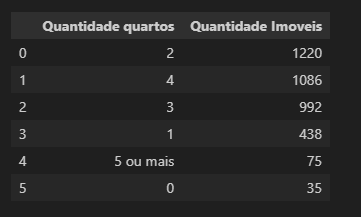

VIVAREAL:

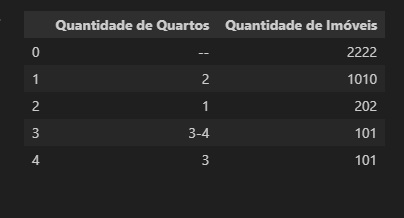

## Faixa de preço predominante por m².
OLX:

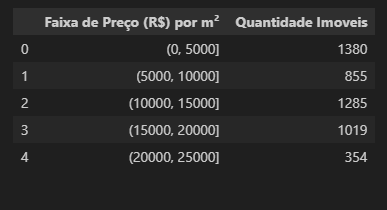

VIVAREAL:

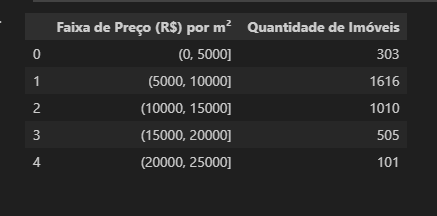

# Quanto tempo seria necessário para implementar e rodar a solução proposta?


### O tempo necessário dependerá da quantidade de sites que serão acessados e da frequência das requisições diárias. Estimo que seriam necessários aproximadamente 30 dias para implementar e calibrar a solução para cada site ficar 100%.

### É importante destacar que cada site possui suas próprias regras de proteção de dados e mecanismos de segurança. Os scripts apresentados foram ajustados para atender às particularidades de cada site, incluindo intervalos de tempo configurados para realizar requisições de forma espaçada (e.g., a cada segundo), reduzindo o risco de bloqueio do bot.

### Além disso, é essencial considerar que os sites estão sujeitos a atualizações constantes, o que pode exigir ajustes frequentes (semanais) nos bots para garantir que continuem funcionando conforme esperado. Portanto, a manutenção contínua será necessária para acompanhar essas mudanças.

# Quais recursos (humanos, tecnológicos, etc.) seriam necessários?

### Acredito que no máximo duas pessoas seriam necessárias para acompanhar o funcionamento dos bots e implementar mecanismos de validação, garantindo que as informações corretas cheguem ao cliente final. Além disso, é essencial contar com um bom computador para o desenvolvimento e um servidor dedicado para automatizar a coleta e o processamento dos dados.

# Qualidade dos dados (ex.: precisão, eliminação de duplicidades).


### Para garantir a qualidade dos dados, é fundamental definir claramente as regras de negócio, estabelecendo quais campos serão necessários nas bases de dados e compreendendo as limitações dos sites, que podem não disponibilizar todas as informações desejadas. Além disso, recomenda-se manter apenas os anúncios mais recentes, com um limite de 60 dias, excluindo os mais antigos periodicamente.

### A questão da duplicidade pode ser abordada de diferentes formas, considerando que podem existir anúncios falsos, duplicados pelo mesmo proprietário ou o mesmo imóvel sendo anunciado por diferentes corretores com variações de preço. Para lidar com isso, seria necessário um estudo detalhado para identificar padrões de duplicação e aplicar regras específicas para filtragem e consolidação dos dados.

# Escalabilidade (ex.: replicar para outros bairros ou cidades).


### A escalabilidade da solução é ampla, permitindo sua replicação para diferentes bairros e cidades sem grandes limitações. Uma vez que o bot esteja desenvolvido, ele poderá ser ajustado para coletar dados de diversas regiões, utilizando uma lista de links fixos das áreas desejadas.

### No entanto, é importante considerar que o aumento no volume de requisições pode impactar o desempenho dos sites de origem, tornando-os mais lentos ou até resultando em bloqueios temporários. Para mitigar esses riscos, é possível distribuir as requisições ao longo do dia, ajustando a frequência de acesso.

### Além disso, conforme a escalabilidade aumenta, cresce também a necessidade de maior capacidade de processamento. Isso exigirá investimentos em infraestrutura computacional mais robusta, como servidores dedicados ou serviços em nuvem, para garantir que a coleta de dados ocorra de maneira eficiente e sem interrupções.